In [35]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib.path as mpath
from matplotlib.patches import Ellipse
from scipy.odr import ODR, Model, Data
from scipy import constants
from scipy.stats import spearmanr

# from astropy.io import fits
# from astropy.wcs import WCS
# from astropy.convolution import Gaussian2DKernel, convolve


In [36]:
LINUX_DIRECTORY = "/scratch/nas_comap1/jgalla/MPHYS_PROJECT"

PS_DATA_DIR = f"{LINUX_DIRECTORY}/data/pointing_byhand"

FILE_NAME = "GDIGS_PS_COORDS.csv"

In [37]:
# read in data
GDIGS_poserr = 0.125/60
COMAP_poserr = 0.25/60
Eff_poserr = 0.5/60

raw_data = np.genfromtxt(f"{PS_DATA_DIR}/{FILE_NAME}", dtype=str, skip_header=1, delimiter=',')

GDIGS_l = np.zeros_like(raw_data[:,0], dtype=float)
GDIGS_b = np.zeros_like(raw_data[:,0], dtype=float)
GDIGS_info = np.zeros_like(raw_data[:,0], dtype=float)
COMAP_l = np.zeros_like(raw_data[:,0], dtype=float)
COMAP_b = np.zeros_like(raw_data[:,0], dtype=float)
COMAP_info = np.zeros_like(raw_data[:,0], dtype=float)
Eff_l = np.zeros_like(raw_data[:,0], dtype=float)
Eff_b = np.zeros_like(raw_data[:,0], dtype=float)
Eff_info = np.zeros_like(raw_data[:,0], dtype=float)
for i, v in enumerate(raw_data[:,1]):
    try:
        GDIGS_l[i] = v.strip(" ")
    except ValueError:
        GDIGS_l[i] = np.nan
    try:
        GDIGS_b[i] = raw_data[i,2].strip(" ")
    except ValueError:
        GDIGS_b[i] = np.nan
    
    try:
        COMAP_l[i] = raw_data[i,4].strip(" ")
    except ValueError:
        COMAP_l[i] = np.nan
    
    try:
        COMAP_b[i] = raw_data[i,5].strip(" ")
    except ValueError:
        COMAP_b[i] = np.nan
    
    try:
        Eff_l[i] = raw_data[i,7].strip(" ")
    except ValueError:
        Eff_l[i] = np.nan
    try:
        Eff_b[i] = raw_data[i,8].strip(" ")
    except ValueError:
        Eff_b[i] = np.nan

    print(f"{i}; Added row: GDIGS ({GDIGS_l[i]}, {GDIGS_b[i]}), CO26 ({COMAP_l[i]}, {COMAP_b[i]}) Eff2.7 ({Eff_l[i]}, {Eff_b[i]})")


GDIGS_poserrs = np.full_like(GDIGS_l, GDIGS_poserr)
COMAP_poserrs = np.full_like(COMAP_l, COMAP_poserr)
Eff_poserrs = np.full_like(COMAP_l, Eff_poserr)

0; Added row: GDIGS (18.146, -0.285), CO26 (18.145, -0.291) Eff2.7 (nan, nan)
1; Added row: GDIGS (19.067, -0.275), CO26 (19.067, -0.265) Eff2.7 (nan, nan)
2; Added row: GDIGS (19.61, -0.233), CO26 (19.604, -0.237) Eff2.7 (nan, nan)
3; Added row: GDIGS (20.074, -0.137), CO26 (20.072, -0.138) Eff2.7 (nan, nan)
4; Added row: GDIGS (20.737, -0.086), CO26 (nan, nan) Eff2.7 (20.731, -0.095)
5; Added row: GDIGS (20.747, -0.087), CO26 (20.741, -0.085) Eff2.7 (nan, nan)
6; Added row: GDIGS (20.762, -0.483), CO26 (nan, nan) Eff2.7 (nan, nan)
7; Added row: GDIGS (20.984, 0.096), CO26 (20.985, 0.093) Eff2.7 (nan, nan)
8; Added row: GDIGS (nan, nan), CO26 (nan, nan) Eff2.7 (21.049, 1.957)
9; Added row: GDIGS (nan, nan), CO26 (21.502, -0.878) Eff2.7 (21.501, -0.885)
10; Added row: GDIGS (nan, nan), CO26 (23.113, 0.555) Eff2.7 (23.102, 0.547)
11; Added row: GDIGS (nan, nan), CO26 (23.425, -0.2) Eff2.7 (23.413, -0.204)
12; Added row: GDIGS (nan, nan), CO26 (23.544, -0.025) Eff2.7 (23.549, -0.0138)
13

In [38]:
# COMAP vs GDIGS

l_diffs = (GDIGS_l - COMAP_l) * 3600
b_diffs = (GDIGS_b - COMAP_b) * 3600
differrs = np.sqrt(GDIGS_poserrs**2 + COMAP_poserrs**2) * 3600

w_dl = 1 / differrs**2
w_db = 1 / differrs**2

m_ldiffs = np.nansum(l_diffs * w_dl) / np.nansum(w_dl)
m_bdiffs = np.nansum(b_diffs * w_db) / np.nansum(w_db)

# Incerteza da média ponderada
# m_differr = np.sqrt(1 / np.sum(w_dl))
m_differr = np.sqrt(1 / np.nansum(w_db))

L_place = GDIGS_l
B_place = GDIGS_b


# m_ldiffs, m_bdiffs = np.nanmean(l_diffs), np.nanmean(b_diffs)
# m_differr = np.nanmean(differrs)/np.sqrt(len(l_diffs))

print(f"Mean Pointing error: ({m_ldiffs} +/- {m_differr}, {m_bdiffs} +/- {m_differr})")

for i, v in enumerate(l_diffs):
    print(f"{i}: ({v}, {b_diffs[i]})")

Mean Pointing error: (1.1897278220735584e-12 +/- 2.5574787730142754, -2.511627906976748 +/- 2.5574787730142754)
0: (3.6000000000043997, 21.60000000000002)
1: (0.0, -36.00000000000003)
2: (21.60000000000082, 14.399999999999913)
3: (7.200000000008799, 3.600000000000003)
4: (nan, nan)
5: (21.60000000000082, -7.199999999999957)
6: (nan, nan)
7: (-3.59999999999161, 10.80000000000001)
8: (nan, nan)
9: (nan, nan)
10: (nan, nan)
11: (nan, nan)
12: (nan, nan)
13: (21.60000000000082, 17.999999999999915)
14: (-10.80000000000041, -14.399999999999963)
15: (-25.20000000000522, 0.0)
16: (nan, nan)
17: (-21.60000000000082, -3.600000000000003)
18: (nan, nan)
19: (-7.19999999999601, 7.200000000000006)
20: (nan, nan)
21: (nan, nan)
22: (nan, nan)
23: (nan, nan)
24: (-7.19999999999601, 0.0)
25: (-21.60000000000082, -28.800000000000026)
26: (nan, nan)
27: (-10.80000000000041, -14.400000000000013)
28: (0.0, -39.60000000000004)
29: (0.0, -39.60000000000004)
30: (28.800000000009618, -28.800000000000026)
31: (

In [ ]:
# COMAP vs Effelsberg

l_diffs = (Eff_l - COMAP_l) * 3600
b_diffs = (Eff_b - COMAP_b) * 3600
differrs = np.sqrt(Eff_poserrs**2 + COMAP_poserrs**2) * 3600

w_dl = 1 / differrs**2
w_db = 1 / differrs**2

m_ldiffs = np.nansum(l_diffs * w_dl) / np.nansum(w_dl)
m_bdiffs = np.nansum(b_diffs * w_db) / np.nansum(w_db)

m_differr = np.sqrt(1 / np.nansum(w_db))

L_place = Eff_l
B_place = Eff_b

# m_ldiffs, m_bdiffs = np.nanmean(l_diffs), np.nanmean(b_diffs)
# m_differr = np.nanmean(differrs)/np.sqrt(len(l_diffs))

print(f"Mean Pointing error: ({m_ldiffs} +/- {m_differr}, {m_bdiffs} +/- {m_differr})")

for i, v in enumerate(l_diffs):
    print(f"{i}: ({v}, {b_diffs[i]})")

Mean Pointing error: (-6.446511627907122 +/- 5.114957546028551, -4.671627906976737 +/- 5.114957546028551)
0: (nan, nan)
1: (nan, nan)
2: (nan, nan)
3: (nan, nan)
4: (nan, nan)
5: (nan, nan)
6: (nan, nan)
7: (nan, nan)
8: (nan, nan)
9: (-3.59999999999161, -25.200000000000024)
10: (-39.59999999999724, -28.800000000000026)
11: (-43.20000000000164, -14.399999999999913)
12: (17.99999999999642, 40.32000000000001)
13: (-36.00000000000563, 0.0)
14: (nan, nan)
15: (nan, nan)
16: (nan, nan)
17: (nan, nan)
18: (17.99999999999642, -3.600000000000003)
19: (nan, nan)
20: (nan, nan)
21: (-21.60000000000082, -39.60000000000004)
22: (nan, nan)
23: (-43.20000000000164, -28.799999999999926)
24: (-7.19999999999601, -35.99999999999983)
25: (nan, nan)
26: (nan, nan)
27: (nan, nan)
28: (-50.39999999999765, 0.0)
29: (nan, nan)
30: (nan, nan)
31: (nan, nan)
32: (nan, nan)
33: (nan, nan)
34: (-50.39999999999765, -28.8)
35: (nan, nan)
36: (nan, nan)
37: (-18.00000000000921, -35.99999999999998)
38: (nan, nan)
39:

Δl vs RA
Chi-square = 5.47
DoF = 10
Reduced chi-square = 0.55
Δl vs RA
Chi-square = 5.47
DoF = 10
Reduced chi-square = 0.55


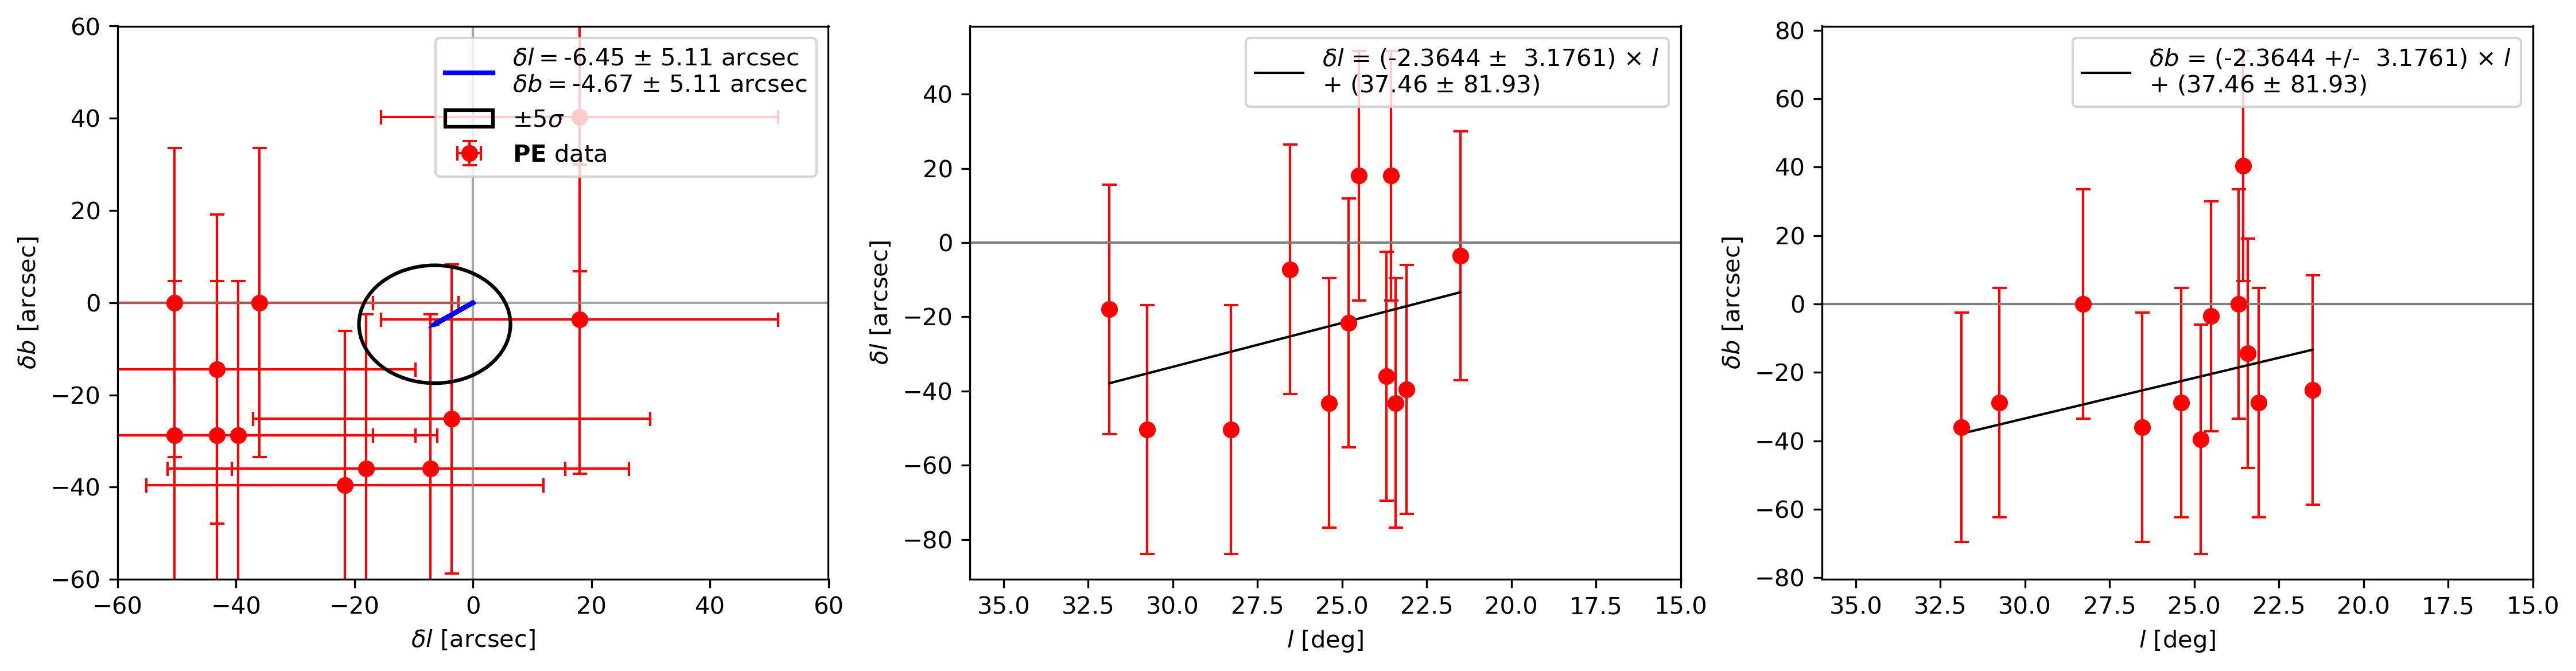

In [ ]:
def remove_nans_tup(array_of_arrays): # array_of_arrays in form [np.array(a1), np,array(a2), etc.]
        mask = np.any([np.isnan(array) for array in array_of_arrays], axis=0)
        return tuple(array[~mask] for array in array_of_arrays)

fontsize = 10

fig_fin, axs_fin = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), dpi=300)

arrow_label = r"$\delta l = $"+f"{m_ldiffs:.2f} ± {m_differr:.2f} arcsec\n" + r"$\delta b = $" + f"{m_bdiffs:.2f} ± {m_differr:.2f} arcsec"

axs_fin[0].errorbar(l_diffs, b_diffs, xerr=differrs, yerr=differrs, 
             fmt='ro', label=r'$\mathbf{PE}$ data', capsize=3, elinewidth=1)

axs_fin[0].set_xlabel(r'$\delta l$ [arcsec]', fontsize=fontsize)
axs_fin[0].set_ylabel(r'$\delta b$ [arcsec]', fontsize=fontsize)
axs_fin[0].tick_params(axis='x', labelsize=fontsize, bottom=True, labelbottom=True)
axs_fin[0].tick_params(axis='y', labelsize=fontsize, left=True, right=False)

axs_fin[0].axhline(0, color='gray', linewidth=1, alpha=0.7)
axs_fin[0].axvline(0, color='gray', linewidth=1, alpha=0.7)

axs_fin[0].plot([], [], color='blue', linewidth=2, label=arrow_label)
axs_fin[0].plot(0,0,'bo', markersize=1)

ellipse = Ellipse((m_ldiffs, m_bdiffs), m_differr*5, m_differr*5, linewidth=1.5, fill=False, color='black', zorder=99, label=r"$\pm 5 \sigma$")
axs_fin[0].add_patch(ellipse)

axs_fin[0].arrow(0, 0, m_ldiffs, m_bdiffs, 
                 color='blue', 
                 linewidth=2, 
                 length_includes_head=True,
                 head_width=0.05,
                 zorder=100)


axs_fin[0].set_xlim(-60, 60)
axs_fin[0].set_ylim(-60, 60)

axs_fin[0].legend(fontsize=fontsize)

axs_fin[1].errorbar(L_place, l_diffs, yerr=differrs, fmt='ro', capsize=3, elinewidth=1)
axs_fin[1].set_xlim(36, 15)
axs_fin[1].set_xlabel(r'$l$ [deg]', fontsize=fontsize)
axs_fin[1].set_ylabel(R'$\delta l$ [arcsec]', fontsize=fontsize)
axs_fin[1].tick_params(axis='x', labelsize=fontsize, bottom=True, labelbottom=True)
axs_fin[1].tick_params(axis='y', labelsize=fontsize, left=True, right=False)
axs_fin[1].axhline(0, color='gray', linewidth=1)

x_d = np.array(L_place)
y_d = l_diffs
yerr_d = differrs

x, y, yerr = remove_nans_tup([x_d, y_d, yerr_d])

w = 1 / yerr**2

A = np.vstack([x, np.ones_like(x)]).T
C = np.diag(w)
cov = np.linalg.inv(A.T @ C @ A)
m, c = cov @ (A.T @ C @ y)
m_err, c_err = np.sqrt(np.diag(cov))

x_line = np.linspace(np.min(x), np.max(x), 200)
y_line = m * x_line + c
# axes[0,0].plot(x_line, y_line, color='black', linewidth=1,
#                label=rf'$\delta l$ = ({m:.4f} $\pm$ {m_err: .4f}) $\times$ $l$'+'\n'+rf'+ ({c:.2f} $\pm$ {c_err:.2f})')
axs_fin[1].plot(x_line, y_line, color='black', linewidth=1,
               label=rf'$\delta l$ = ({m:.4f} $\pm$ {m_err: .4f}) $\times$ $l$'+'\n'+rf'+ ({c:.2f} $\pm$ {c_err:.2f})')

axs_fin[1].legend(fontsize=fontsize)

# Chi-square
y_model = m * x + c
chisq = np.sum(((y - y_model) / yerr)**2)
ndof = len(x) - 2
chisq_red = chisq / ndof

print("Δl vs RA")
print(f"Chi-square = {chisq:.2f}")
print(f"DoF = {ndof}")
print(f"Reduced chi-square = {chisq_red:.2f}")

# axes[0,1].errorbar(HII_longitude, lb_delta[:,1], yerr=lb_error[:,1], fmt='ro', capsize=3, elinewidth=1)
# axes[0,1].set_xlim(160, 15)
# axes[0,1].set_xlabel(r'$l$ [deg]')
# axes[0,1].set_ylabel(r'$\delta b$ [arcmin]')
# axes[0,1].axhline(0, color='gray', linewidth=1)


axs_fin[2].errorbar(L_place, b_diffs, yerr=differrs, fmt='ro', capsize=3, elinewidth=1)
axs_fin[2].set_xlim(36, 15)
axs_fin[2].set_xlabel(r'$l$ [deg]', fontsize=fontsize)
axs_fin[2].set_ylabel(r'$\delta b$ [arcsec]', fontsize=fontsize)
axs_fin[2].tick_params(axis='x', labelsize=fontsize, bottom=True, labelbottom=True)
axs_fin[2].tick_params(axis='y', labelsize=fontsize, left=True, right=False)
axs_fin[2].axhline(0, color='gray', linewidth=1)

x_d = np.array(L_place)
y_d = l_diffs
yerr_d = differrs

x, y, yerr = remove_nans_tup([x_d, y_d, yerr_d])

w = 1 / yerr**2

A = np.vstack([x, np.ones_like(x)]).T
C = np.diag(w)
cov = np.linalg.inv(A.T @ C @ A)
m, c = cov @ (A.T @ C @ y)
m_err, c_err = np.sqrt(np.diag(cov))

x_line = np.linspace(np.min(x), np.max(x), 200)
y_line = m * x_line + c
# axes[0,1].plot(x_line, y_line, color='black', linewidth=1,
#                label=rf'$\delta b$ = ({m:.4f} +/- {m_err: .4f}) $\times$ $l$'+'\n'+rf'+ ({c:.2f} $\pm$ {c_err:.2f})')

# axes[0,1].legend()


axs_fin[2].plot(x_line, y_line, color='black', linewidth=1,
               label=rf'$\delta b$ = ({m:.4f} +/- {m_err: .4f}) $\times$ $l$'+'\n'+rf'+ ({c:.2f} $\pm$ {c_err:.2f})')

axs_fin[2].legend(fontsize=fontsize)

# Chi-square
y_model = m * x + c
chisq = np.sum(((y - y_model) / yerr)**2)
ndof = len(x) - 2
chisq_red = chisq / ndof

print("Δl vs RA")
print(f"Chi-square = {chisq:.2f}")
print(f"DoF = {ndof}")
print(f"Reduced chi-square = {chisq_red:.2f}")

# axes[1,0].errorbar(HII_latitude, lb_delta[:,0], yerr=lb_error[:,0], fmt='ro', capsize=3, elinewidth=1)
# axes[1,0].set_xlim(-3, 3)
# axes[1,0].set_ylim(-1.5, 1.5)
# axes[1,0].set_xlabel(r'$b$ [deg]')
# axes[1,0].set_ylabel(r'$\delta l$ [arcmin]')
# axes[1,0].axhline(0, color='gray', linewidth=1)

# axes[1,1].errorbar(HII_latitude, lb_delta[:,1], yerr=lb_error[:,1], fmt='ro', capsize=3, elinewidth=1)
# axes[1,1].set_xlim(-3, 3)
# axes[1,1].set_ylim(-2, 2)
# axes[1,1].set_xlabel(r'$b$ [deg]')
# axes[1,1].set_ylabel(r'$\delta b$ [arcmin]')
# axes[1,1].axhline(0, color='gray', linewidth=1)

# plt.tight_layout()
fig_fin.tight_layout()
plt.show()

Chi-square = 5.47
DoF = 10
Reduced chi-square = 0.55
Chi-square = 4.67
DoF = 10
Reduced chi-square = 0.47


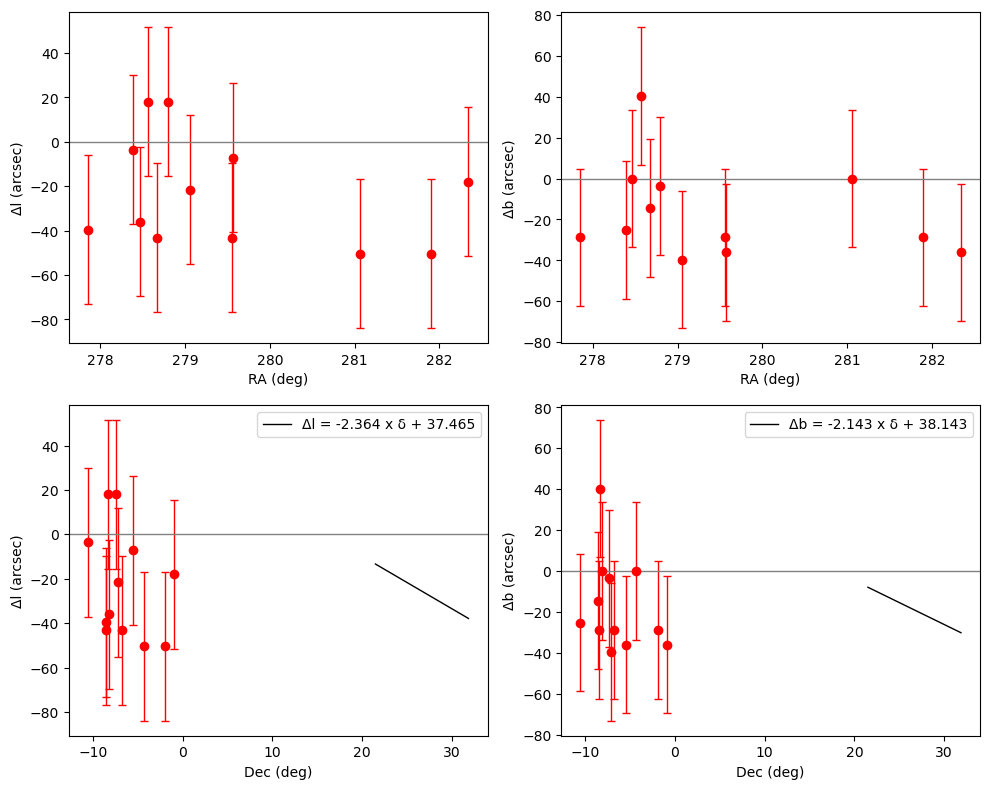

In [43]:
# RA and Dec

from astropy.coordinates import SkyCoord
import astropy.units as u

coords_gal = SkyCoord(l=L_place*u.deg, b=B_place*u.deg, frame='galactic')
coords_icrs = coords_gal.icrs

RA  = coords_icrs.ra.to(u.deg).value
DEC = coords_icrs.dec.to(u.deg).value

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=100)

# Panel 1: Δl vs RA
axes[0,0].errorbar(RA, l_diffs, yerr=differrs,
                   fmt='ro', capsize=3, elinewidth=1)
axes[0,0].set_xlabel('RA (deg)')
axes[0,0].set_ylabel('Δl (arcsec)')
axes[0,0].axhline(0, color='gray', linewidth=1)

# Panel 2: Δb vs RA
axes[0,1].errorbar(RA, b_diffs, yerr=differrs,
                   fmt='ro', capsize=3, elinewidth=1)
axes[0,1].set_xlabel('RA (deg)')
axes[0,1].set_ylabel('Δb (arcsec)')
axes[0,1].axhline(0, color='gray', linewidth=1)

# Panel 3: Δl vs Dec
axes[1,0].errorbar(DEC, l_diffs, yerr=differrs,
                   fmt='ro', capsize=3, elinewidth=1)
axes[1,0].set_xlabel('Dec (deg)')
axes[1,0].set_ylabel('Δl (arcsec)')
axes[1,0].axhline(0, color='gray', linewidth=1)

# Ajuste linear ponderado
x = DEC
y_d = l_diffs
yerr_d = differrs

x, y, yerr = remove_nans_tup([x_d, y_d, yerr_d])
w = 1 / yerr**2

A = np.vstack([x, np.ones_like(x)]).T
C = np.diag(w)
cov = np.linalg.inv(A.T @ C @ A)
m, c = cov @ (A.T @ C @ y)
m_err, c_err = np.sqrt(np.diag(cov))

x_line = np.linspace(np.min(x), np.max(x), 200)
y_line = m * x_line + c
axes[1,0].plot(x_line, y_line, color='black', linewidth=1,
               label=f'Δl = {m:.3f} x δ + {c:.3f}')

# Chi-square
y_model = m * x + c
chisq = np.sum(((y - y_model) / yerr)**2)
ndof = len(x) - 2
chisq_red = chisq / ndof

print(f"Chi-square = {chisq:.2f}")
print(f"DoF = {ndof}")
print(f"Reduced chi-square = {chisq_red:.2f}")

axes[1,0].legend()

# Panel 4: Δb vs Dec
axes[1,1].errorbar(DEC, b_diffs, yerr=differrs,
                   fmt='ro', capsize=3, elinewidth=1)
axes[1,1].set_xlabel('Dec (deg)')
axes[1,1].set_ylabel('Δb (arcsec)')
axes[1,1].axhline(0, color='gray', linewidth=1)

# Ajuste linear ponderado
x = DEC
y_d = b_diffs
yerr_d = differrs

x, y, yerr = remove_nans_tup([x_d, y_d, yerr_d])
w = 1 / yerr**2

A = np.vstack([x, np.ones_like(x)]).T
C = np.diag(w)
cov = np.linalg.inv(A.T @ C @ A)
m, c = cov @ (A.T @ C @ y)
m_err, c_err = np.sqrt(np.diag(cov))

x_line = np.linspace(np.min(x), np.max(x), 200)
y_line = m * x_line + c
axes[1,1].plot(x_line, y_line, color='black', linewidth=1,
               label=f'Δb = {m:.3f} x δ + {c:.3f}')

# Chi-square
y_model = m * x + c
chisq = np.sum(((y - y_model) / yerr)**2)
ndof = len(x) - 2
chisq_red = chisq / ndof

print(f"Chi-square = {chisq:.2f}")
print(f"DoF = {ndof}")
print(f"Reduced chi-square = {chisq_red:.2f}")

axes[1,1].legend()

plt.tight_layout()
plt.show()